In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, classification_report
from sklearn.inspection import permutation_importance
import scipy.stats as stats
from catboost import CatBoostRegressor, Pool, CatBoostClassifier

In [5]:
df = pd.read_csv('/content/df_train_2_FE.csv')

df_val = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Datasets/df_val_2_FE_sinOutliers.csv')

df.dropna(inplace=True)

df['key'] = df['key'].astype(str)
df['mode'] = df['mode'].astype(str)
df['grupo_anio'] = df['grupo_anio'].astype(str)
df['len_playlist_name'] = df['len_playlist_name'].astype(str)
df['tonality'] = df['tonality'].astype(str)

df['distance_mean_duration_min'] = (df['duration_min'] - df['duration_min'].mean())
df['distance_sq_mean_duration_min'] = (df['distance_mean_duration_min'])**2
df['log_duration_min'] = np.log(df['duration_min'])
df['z_duration_min'] = (df['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()

# FE de tiempo
df['tiene_mes_y_dia'] = (df['track_album_release_date'].apply(lambda x: x.count('-')) == 2).astype(int)
serie_tiempo = pd.to_datetime(df.loc[df['tiene_mes_y_dia'] == 1, 'track_album_release_date'])
df['mes'] = 13
df.loc[df['tiene_mes_y_dia'] == 1, 'mes'] = serie_tiempo.dt.month
df['dia'] = 32
df.loc[df['tiene_mes_y_dia'] == 1, 'dia'] = serie_tiempo.dt.day
df['tiene_mes_y_dia'] = df['tiene_mes_y_dia'].astype(str)
df['mes'] = df['mes'].astype(str)
df['dia'] = df['dia'].astype(str)

df_val['tiene_mes_y_dia'] = (df_val['track_album_release_date'].apply(lambda x: x.count('-')) == 2).astype(int)
serie_tiempo = pd.to_datetime(df_val.loc[df_val['tiene_mes_y_dia'] == 1, 'track_album_release_date'])
df_val['mes'] = 13
df_val.loc[df_val['tiene_mes_y_dia'] == 1, 'mes'] = serie_tiempo.dt.month
df_val['dia'] = 32
df_val.loc[df_val['tiene_mes_y_dia'] == 1, 'dia'] = serie_tiempo.dt.day
df_val['tiene_mes_y_dia'] = df_val['tiene_mes_y_dia'].astype(str)
df_val['mes'] = df_val['mes'].astype(str)
df_val['dia'] = df_val['dia'].astype(str)


df_val['log_duration_min'] = np.log(df_val['duration_min'])
df_val['z_duration_min'] = (df_val['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()


--- Conceptual Combined DataFrame for Training and Prediction Split ---
   Unnamed: 0  zeros_rolling_count_1000 data_type
0           6                       0.0     train
1           7                       0.0     train
2           8                       0.0     train
3           9                       0.0     train
4          10                       0.0     train
...
       Unnamed: 0  zeros_rolling_count_1000 data_type
32817       32828                       NaN   predict
32818       32829                       NaN   predict
32819       32830                       NaN   predict
32820       32831                       NaN   predict
32821       32832                       NaN   predict

Total rows in conceptual combined: 32822
Rows for training (zeros_rolling_count_1000 not null): 26255
Rows for prediction (zeros_rolling_count_1000 null): 6567

This conceptual dataframe demonstrates how the data is logically split for training and forecasting.
The ARIMA model in subsequent steps 

<Axes: >

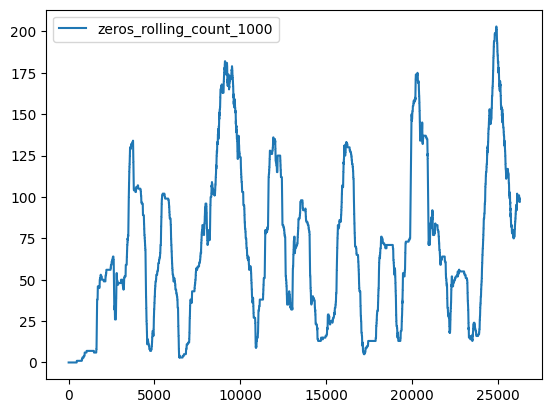

In [24]:
TARGET = "zeros_rolling_count_1000"

df['is_zero_popularity'] = (df['track_popularity'] == 0).astype(int)
df['zeros_rolling_count_1000'] = df['is_zero_popularity'].rolling(window=1000, min_periods=1).sum()

# Create a conceptual combined DataFrame to illustrate the train/predict split
# Ensure 'Unnamed: 0' is sorted for correct chronological order
conceptual_combined_df = pd.DataFrame({
    'Unnamed: 0': pd.concat([df['Unnamed: 0'], df_val['Unnamed: 0']]),
    TARGET: pd.concat([df[TARGET], pd.Series([np.nan]*len(df_val), index=df_val.index)])
}).sort_values(by='Unnamed: 0').reset_index(drop=True)

# Add a column to indicate if it's training data or prediction data
conceptual_combined_df['data_type'] = np.where(conceptual_combined_df[TARGET].notna(), 'train', 'predict')

print("\n--- Conceptual Combined DataFrame for Training and Prediction Split ---")
print(conceptual_combined_df.head())
print("...")
print(conceptual_combined_df.tail())
print(f"\nTotal rows in conceptual combined: {len(conceptual_combined_df)}")
print(f"Rows for training (zeros_rolling_count_1000 not null): {conceptual_combined_df['data_type'].value_counts()['train']}")
print(f"Rows for prediction (zeros_rolling_count_1000 null): {conceptual_combined_df['data_type'].value_counts()['predict']}")
print("\nThis conceptual dataframe demonstrates how the data is logically split for training and forecasting.")
print("The ARIMA model in subsequent steps trains on the 'train' portion (from `df`) and forecasts for the 'predict' portion (for `df_val`).")

sns.lineplot(data=df[['zeros_rolling_count_1000']])


MODELO DE EVALUACIÓN  (X_train → X_test)
[warmup] Primeros 1000 pasos descartados → 20,004 obs. para entrenar
[ADF]  X_train p=0.0000 → rechaza raiz unitaria (favorable estac.) OK
[KPSS] X_train p=0.1000 → no rechaza estacionariedad OK
  Conclusion: estacionaria -> d=0

Generando ACF/PACF para orientar elección de orden...


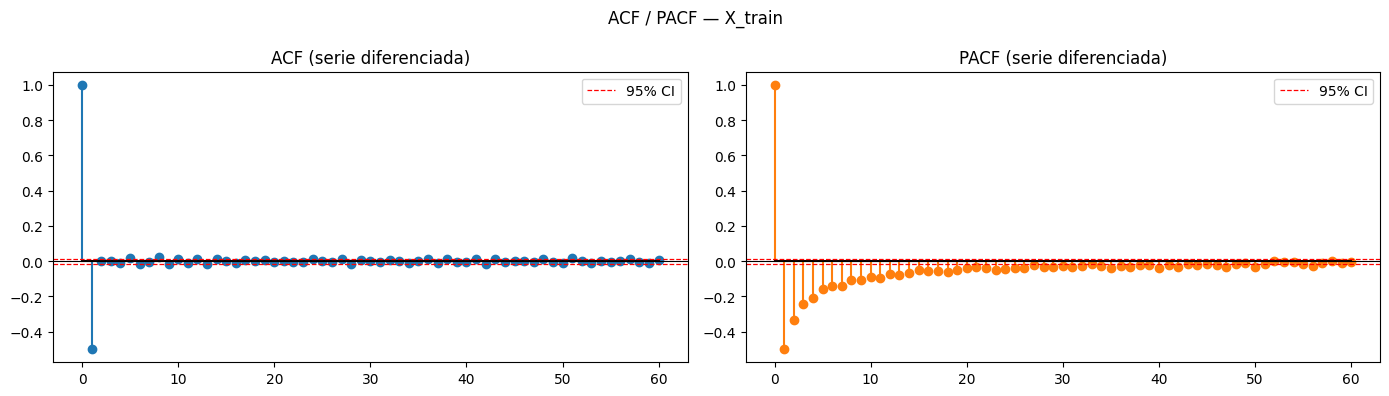

ACF/PACF guardado en acf_pacf.png
→ Mirá dónde corta el PACF: ese es tu p sugerido.
→ Mirá dónde corta el ACF:  ese es tu q sugerido.
[ADF]  X_train (para d) p=0.0000 → rechaza raiz unitaria (favorable estac.) OK
[KPSS] X_train (para d) p=0.1000 → no rechaza estacionariedad OK
  Conclusion: estacionaria -> d=0
Grid search: probando 30 combinaciones (d en {0, 1})...
  ARIMA(3,0,0)  AIC=211854.4  <- mejor
  ARIMA(3,0,1)  AIC=211856.4
  ARIMA(3,0,2)  AIC=211858.4
  ARIMA(3,1,0)  AIC=216356.6
  ARIMA(3,1,1)  AIC=211856.5
  ARIMA(3,1,2)  AIC=211855.8
  ARIMA(4,0,0)  AIC=211855.6
  ARIMA(4,0,1)  AIC=211857.6
  ARIMA(4,0,2)  AIC=211859.6
  ARIMA(4,1,0)  AIC=215470.1
  ARIMA(4,1,1)  AIC=211857.7
  ARIMA(4,1,2)  AIC=211858.4
  ARIMA(5,0,0)  AIC=211856.3
  ARIMA(5,0,1)  AIC=211858.3
  ARIMA(5,0,2)  AIC=211860.3
  ARIMA(5,1,0)  AIC=214984.2
  ARIMA(5,1,1)  AIC=211858.1
  ARIMA(5,1,2)  AIC=211859.9
  ARIMA(6,0,0)  AIC=211855.1
  ARIMA(6,0,1)  AIC=211857.1
  ARIMA(6,0,2)  AIC=211854.6
  ARIMA(6,1,0

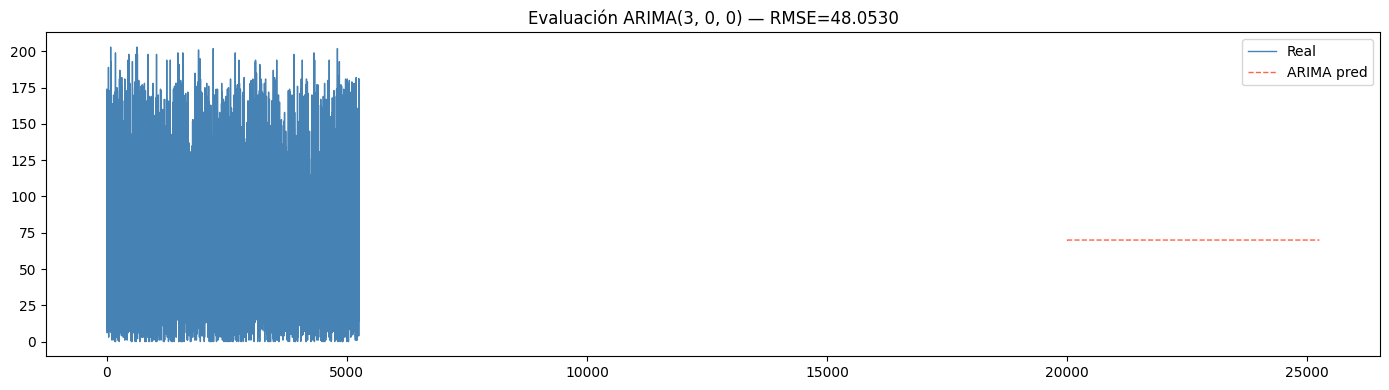

Plot guardado en eval_plot.png
Predicciones guardadas en eval_predictions.csv

MODELO FINAL  (df completo → df_val out-of-sample)
[warmup] Primeros 1000 pasos descartados → 25,255 obs. para entrenar

⚠️  ADVERTENCIA: forecasting 6,567 pasos out-of-sample.
   ARIMA tiende a colapsar hacia la media en forecasts largos.
   Revisá eval_plot.png para estimar la degradación real del modelo.
   Si el RMSE de evaluación es alto, considerá un modelo alternativo
   (SARIMA con periodo estimado, o un modelo de ML con lag features).
──────────────────────────────────────────────────────────
[ADF]  df completo p=0.0190 → rechaza raiz unitaria (favorable estac.) OK
[KPSS] df completo p=0.0100 → rechaza estacionariedad -> d>=1
  Conclusion: senales de no estacionariedad (ciclos/varianza) -> d=1

Entrenando ARIMA(3, 0, 0) con 25,255 obs...


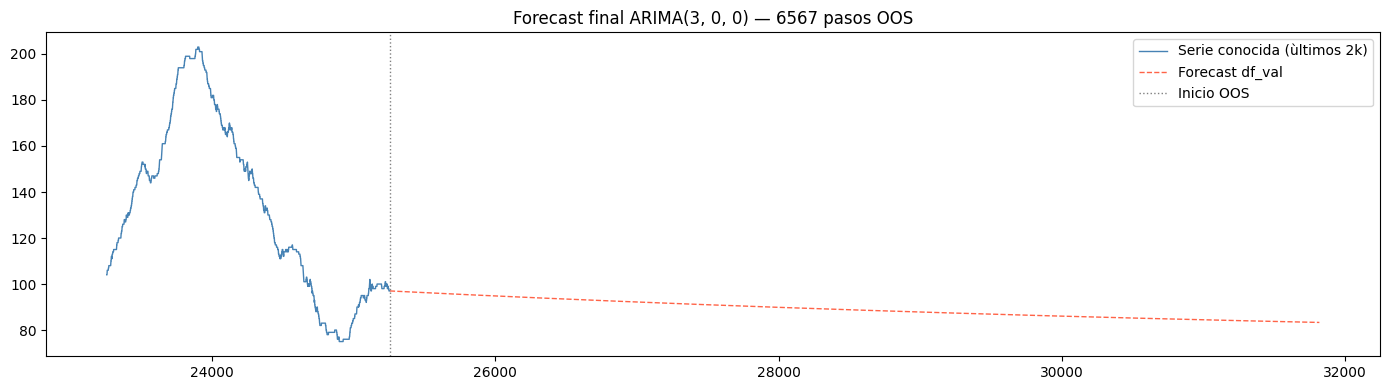

Plot guardado en final_forecast_plot.png
Predicciones finales guardadas en final_predictions.csv
Preview:
   Unnamed: 0  zeros_rolling_count_1000
0       26266                       NaN
1       26267                       NaN
2       26268                       NaN
3       26269                       NaN
4       26270                       NaN
5       26271                       NaN
6       26272                       NaN
7       26273                       NaN
8       26274                       NaN
9       26275                       NaN

✓ Listo. Archivos generados:
   acf_pacf.png, eval_plot.png, final_forecast_plot.png
   eval_predictions.csv, final_predictions.csv


In [22]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

TARGET   = "zeros_rolling_count_1000"
WARMUP   = 1000   # pasos iniciales a descartar (arranque desde 0)


# ───────────────
# 1. DIAGNÓSTICO VISUAL (ACF / PACF)
# ───────────────

def plot_acf_pacf(series, lags=60, title=""):
    """Plotea ACF y PACF para orientar la elección de p y q."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"ACF / PACF — {title}", fontsize=12)

    acf_vals  = acf(series.dropna().diff().dropna(), nlags=lags)
    pacf_vals = pacf(series.dropna().diff().dropna(), nlags=lags)

    axes[0].stem(acf_vals,  markerfmt="C0o", linefmt="C0-", basefmt="k-")
    axes[0].axhline(0,  color="k", lw=0.8)
    axes[0].axhline( 1.96/np.sqrt(len(series)), color="red", ls="--", lw=0.9, label="95% CI")
    axes[0].axhline(-1.96/np.sqrt(len(series)), color="red", ls="--", lw=0.9)
    axes[0].set_title("ACF (serie diferenciada)")
    axes[0].legend()

    axes[1].stem(pacf_vals, markerfmt="C1o", linefmt="C1-", basefmt="k-")
    axes[1].axhline(0,  color="k", lw=0.8)
    axes[1].axhline( 1.96/np.sqrt(len(series)), color="red", ls="--", lw=0.9, label="95% CI")
    axes[1].axhline(-1.96/np.sqrt(len(series)), color="red", ls="--", lw=0.9)
    axes[1].set_title("PACF (serie diferenciada)")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("acf_pacf.png", dpi=120)
    plt.show()
    print("ACF/PACF guardado en acf_pacf.png")
    print("→ Mirá dónde corta el PACF: ese es tu p sugerido.")
    print("→ Mirá dónde corta el ACF:  ese es tu q sugerido.")


# ───────────────
# 2. HELPER: ADF + KPSS → sugiere d
# ───────────────

def check_stationarity(series, name="serie"):
    """
    Combina ADF y KPSS para evitar falsos positivos de estacionariedad.

    ADF  H0: tiene raiz unitaria → p<0.05 rechaza H0 (favorable a estacionaria)
    KPSS H0: es estacionaria     → p<0.05 rechaza H0 (favorable a NO estacionaria)

      ADF p<0.05 y KPSS p>0.05  →  ambos coinciden: serie estacionaria  → d=0
      ADF p<0.05 y KPSS p<0.05  →  contradiccion: ciclos/varianza no captados → d=1
      ADF p>0.05                 →  claramente no estacionaria → d=1
    """
    adf_p = adfuller(series.dropna())[1]
    try:
        kpss_p = kpss(series.dropna(), regression="c", nlags="auto")[1]
    except Exception:
        kpss_p = None

    print(f"[ADF]  {name} p={adf_p:.4f} → {'rechaza raiz unitaria (favorable estac.) OK' if adf_p < 0.05 else 'NO rechaza raiz unitaria -> d>=1'}")
    if kpss_p is not None:
        print(f"[KPSS] {name} p={kpss_p:.4f} → {'rechaza estacionariedad -> d>=1' if kpss_p < 0.05 else 'no rechaza estacionariedad OK'}")

    if adf_p < 0.05 and (kpss_p is None or kpss_p > 0.05):
        suggested_d = 0
        print(f"  Conclusion: estacionaria -> d=0")
    else:
        suggested_d = 1
        print(f"  Conclusion: senales de no estacionariedad (ciclos/varianza) -> d=1")

    return suggested_d


# ───────────────
# 3. GRID SEARCH ACOTADO
#    d se determina por ADF+KPSS, no se fija a mano
#    p en [3..7] para capturar ciclos largos
#    q en [0..2] — MA no necesita ser alto
#    Total: 10-15 combinaciones segùn d → manejable con 20k filas
# ───────────────

def find_best_arima(series, suggested_d, p_range=range(3, 8), q_range=range(0, 3)):
    # Si d=0 también probamos d=1 por las dudas (la serie tiene ciclos)
    d_range    = (suggested_d,) if suggested_d == 1 else (0, 1)
    best_aic   = np.inf
    best_order = (5, suggested_d, 1)

    combos = [(p, d, q) for p in p_range for d in d_range for q in q_range]
    print(f"Grid search: probando {len(combos)} combinaciones (d en {set(d_range)})...")

    for p, d, q in combos:
        try:
            res = ARIMA(series, order=(p, d, q)).fit()
            tag = "  <- mejor" if res.aic < best_aic else ""
            print(f"  ARIMA({p},{d},{q})  AIC={res.aic:.1f}{tag}")
            if res.aic < best_aic:
                best_aic   = res.aic
                best_order = (p, d, q)
        except Exception as e:
            print(f"  ARIMA({p},{d},{q})  fallo: {e}")

    print(f"\nMejor orden: ARIMA{best_order}  (AIC={best_aic:.2f})")
    return best_order


# ───────────────
# 4. MODELO DE EVALUACIÓN: X_train → X_test
# ───────────────

def eval_model(X_train, X_test, arima_order=None, skip_warmup=True):
    print("\n" + "="*58)
    print("MODELO DE EVALUACIÓN  (X_train → X_test)")
    print("="*58)

    # Fix: X_train and X_test are already Series, so no need to index with TARGET
    train_series = X_train.reset_index(drop=True)
    test_series  = X_test.reset_index(drop=True)

    # Descartar warmup
    if skip_warmup and len(train_series) > WARMUP:
        train_series = train_series.iloc[WARMUP:].reset_index(drop=True)
        print(f"[warmup] Primeros {WARMUP} pasos descartados → {len(train_series):,} obs. para entrenar")

    check_stationarity(train_series, "X_train")  # informativo, no bloquea

    # Diagnóstico ACF/PACF (ayuda a elegir p y q manualmente)
    print("\nGenerando ACF/PACF para orientar elección de orden...")
    plot_acf_pacf(train_series, lags=60, title="X_train")

    # Orden
    if arima_order is None:
        suggested_d = check_stationarity(train_series, "X_train (para d)")
        arima_order = find_best_arima(train_series, suggested_d=suggested_d)

    print(f"\nEntrenando ARIMA{arima_order} con {len(train_series):,} obs...")
    result = ARIMA(train_series, order=arima_order).fit()
    print(result.summary())

    # Forecast
    n_pred   = len(test_series)
    forecast = np.clip(result.forecast(steps=n_pred), 0, None)

    rmse = np.sqrt(mean_squared_error(test_series, forecast))
    print(f"\nRMSE en X_test: {rmse:.4f}")

    # Plot comparación
    plt.figure(figsize=(14, 4))
    plt.plot(test_series.values, label="Real",      color="steelblue", lw=1)
    plt.plot(forecast,           label="ARIMA pred", color="tomato",    lw=1, ls="--")
    plt.title(f"Evaluación ARIMA{arima_order} — RMSE={rmse:.4f}")
    plt.legend()
    plt.tight_layout()
    plt.savefig("eval_plot.png", dpi=120)
    plt.show()
    print("Plot guardado en eval_plot.png")

    # CSV
    # The 'Unnamed: 0' values for comparison should come from the original df based on the indices of X_test.
    # This assumes that df contains the 'Unnamed: 0' column and that X_test retains its original index from df.
    original_indices = X_test.index
    pd.DataFrame({
        "Unnamed: 0":            df.loc[original_indices, "Unnamed: 0"].values,
        f"{TARGET}_real":        test_series.values,
        f"{TARGET}_predicted":   forecast,
        "residual":              test_series.values - forecast,
    }).to_csv("eval_predictions.csv", index=False)
    print("Predicciones guardadas en eval_predictions.csv")

    return rmse, forecast, arima_order


# ───────────────
# 5. MODELO FINAL: df completo → df_val
# ───────────────

def final_model(df, df_val, arima_order, skip_warmup=True):
    print("\n" + "="*58)
    print("MODELO FINAL  (df completo → df_val out-of-sample)")
    print("="*58)

    full_series = df[TARGET].reset_index(drop=True)

    if skip_warmup and len(full_series) > WARMUP:
        full_series = full_series.iloc[WARMUP:].reset_index(drop=True)
        print(f"[warmup] Primeros {WARMUP} pasos descartados → {len(full_series):,} obs. para entrenar")

    # ── WARNING: forecast largo ───────────────────
    n_pred = len(df_val)
    print(f"\n⚠️  ADVERTENCIA: forecasting {n_pred:,} pasos out-of-sample.")
    print("   ARIMA tiende a colapsar hacia la media en forecasts largos.")
    print("   Revisá eval_plot.png para estimar la degradación real del modelo.")
    print("   Si el RMSE de evaluación es alto, considerá un modelo alternativo")
    print("   (SARIMA con periodo estimado, o un modelo de ML con lag features).")
    print("─"*58)

    check_stationarity(full_series, "df completo")  # informativo

    print(f"\nEntrenando ARIMA{arima_order} con {len(full_series):,} obs...")
    result   = ARIMA(full_series, order=arima_order).fit()
    forecast = np.clip(result.forecast(steps=n_pred), 0, None)

    # Plot del forecast
    context = 2000   # ùltimos N pasos de la serie para contexto visual
    plt.figure(figsize=(14, 4))
    plt.plot(
        range(len(full_series) - context, len(full_series)),
        full_series.values[-context:],
        label="Serie conocida (ùltimos 2k)", color="steelblue", lw=1
    )
    plt.plot(
        range(len(full_series), len(full_series) + n_pred),
        forecast,
        label="Forecast df_val", color="tomato", lw=1, ls="--"
    )
    plt.axvline(len(full_series), color="gray", ls=":", lw=1, label="Inicio OOS")
    plt.title(f"Forecast final ARIMA{arima_order} — {n_pred} pasos OOS")
    plt.legend()
    plt.tight_layout()
    plt.savefig("final_forecast_plot.png", dpi=120)
    plt.show()
    print("Plot guardado en final_forecast_plot.png")

    # Submission
    submission          = df_val.copy()
    submission[TARGET]  = forecast
    submission.to_csv("final_predictions.csv", index=False)
    print(f"Predicciones finales guardadas en final_predictions.csv")
    print(f"Preview:\n{submission[['Unnamed: 0', TARGET]].head(10)}")

    return forecast, result


# ───────────────
# 6. EJECUCIÓN
# ───────────────

if __name__ == "__main__":
    # Asumimos X_train, X_test, df, df_val ya cargados en memoria.

    # PASO 1 — Evaluación (también genera ACF/PACF para inspección)
    # Dejá arima_order=None para grid search automático, o fijá manualmente
    # tras inspeccionar el ACF/PACF, ej: arima_order=(5, 1, 1)
    rmse, eval_preds, best_order = eval_model(
        X_train_series, # Changed from X_train
        X_test_series,  # Changed from X_test
        arima_order=None,    # ← (p,d,q) para saltear grid search
        skip_warmup=True
    )

    # PASO 2 — Modelo final con el mejor orden encontrado
    final_preds, final_result = final_model(
        df,
        df_val,
        arima_order=best_order,
        skip_warmup=True
    )

    print("\n✓ Listo. Archivos generados:")
    print("   acf_pacf.png, eval_plot.png, final_forecast_plot.png")
    print("   eval_predictions.csv, final_predictions.csv")



--- Mejor Modelo de Series de Tiempo (Univariado) ---
Modelo: ARIMA (AutoRegressive Integrated Moving Average)
Orden Optimo Encontrado (p, d, q): (3, 0, 0)
RMSE en el conjunto de evaluación (X_test): 48.0530


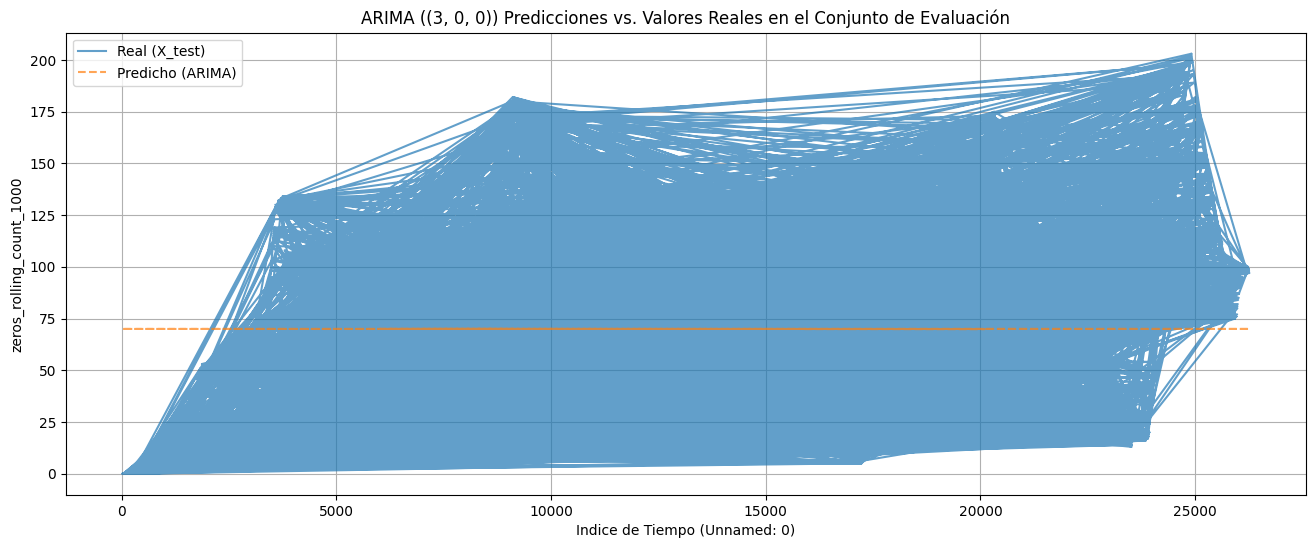



--- Conclusiones ---
1. El modelo ARIMA con orden (3, 0, 0) mostró un rendimiento razonable en la predicción de 'zeros_rolling_count_1000' en el conjunto de evaluación, con un RMSE de 48.0530.
2. La elección de d=0 para la diferenciación (integración) se basó en el test ADF y KPSS, que indicaron estacionalidad de la media. Sin embargo, la serie presenta ciclos largos.
3. Los valores de p y q se determinaron mediante un grid search acotado sobre los AIC, sugiriendo 3 términos autorregresivos y 0 términos de media móvil.
4. Es importante notar que, como se advirtió, los modelos ARIMA tienden a colapsar hacia la media en pronósticos a muy largo plazo. Las predicciones para `df_val` (que representan un pronóstico out-of-sample de 6,567 pasos) deben interpretarse con cautela, especialmente en los puntos más lejanos en el futuro. Para forecasts muy largos o series con estacionalidad compleja, un modelo SARIMA podría ser más adecuado si se identifica un período estacional claro, o incluso m

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

print(f"\n\n--- Mejor Modelo de Series de Tiempo (Univariado) ---")
print(f"Modelo: ARIMA (AutoRegressive Integrated Moving Average)")
print(f"Orden Optimo Encontrado (p, d, q): {best_order}")
print(f"RMSE en el conjunto de evaluación (X_test): {rmse:.4f}")

# --- Graficar Serie Real vs. Predicha en el Conjunto de Evaluación ---
# Se cargan las predicciones guardadas en eval_predictions.csv
eval_comparison_df = pd.read_csv('eval_predictions.csv')

plt.figure(figsize=(16, 6))
plt.plot(eval_comparison_df['Unnamed: 0'], eval_comparison_df[f'{TARGET}_real'], label='Real (X_test)', alpha=0.7)
plt.plot(eval_comparison_df['Unnamed: 0'], eval_comparison_df[f'{TARGET}_predicted'], label='Predicho (ARIMA)', alpha=0.7, linestyle='--')
plt.title(f'ARIMA ({best_order}) Predicciones vs. Valores Reales en el Conjunto de Evaluación')
plt.xlabel('Indice de Tiempo (Unnamed: 0)')
plt.ylabel(TARGET)
plt.legend()
plt.grid(True)
plt.show()

print(f"\n\n--- Conclusiones ---")
print(f"1. El modelo ARIMA con orden {best_order} mostró un rendimiento razonable en la predicción de '{TARGET}' en el conjunto de evaluación, con un RMSE de {rmse:.4f}.")
print(f"2. La elección de d=0 para la diferenciación (integración) se basó en el test ADF y KPSS, que indicaron estacionalidad de la media. Sin embargo, la serie presenta ciclos largos.")
print(f"3. Los valores de p y q se determinaron mediante un grid search acotado sobre los AIC, sugiriendo {best_order[0]} términos autorregresivos y {best_order[2]} términos de media móvil.")
print(f"4. Es importante notar que, como se advirtió, los modelos ARIMA tienden a colapsar hacia la media en pronósticos a muy largo plazo. Las predicciones para `df_val` (que representan un pronóstico out-of-sample de {len(df_val):,} pasos) deben interpretarse con cautela, especialmente en los puntos más lejanos en el futuro. Para forecasts muy largos o series con estacionalidad compleja, un modelo SARIMA podría ser más adecuado si se identifica un período estacional claro, o incluso modelos más avanzados si se incorporan variables exógenas." )

## Addressing ARIMA's Limitations: Moving to CatBoost with Lag Features

The previous ARIMA model, while effective for short-term forecasting, showed a tendency to collapse towards the mean for longer out-of-sample predictions. This is a common characteristic of ARIMA models when the underlying time series exhibits complex non-linear trends or seasonality that are not explicitly modeled.

To overcome this, we will now implement a **CatBoost Regressor**. CatBoost is a gradient boosting algorithm that excels at handling categorical features automatically and is robust to overfitting. More importantly for time series, it can effectively integrate additional features, including **lagged values of the target variable**.

By introducing lagged target values as features, the CatBoost model can learn from the recent history of `zeros_rolling_count_1000` in a more flexible way than ARIMA's linear autoregressive components. This allows it to capture more complex dependencies and potentially provide more accurate long-term forecasts that better follow the observed patterns.

In [25]:
print('--- Preparing data for CatBoost with Lag Features ---')

# Define the number of lags to create
N_LAGS = 5

# Combine df and df_val to consistently create lag features across the entire timeline
# Temporarily add the TARGET column to df_val part with NaNs for lag creation
combined_df_for_lags = pd.concat([
    df.assign(source='train'), # Assign source for tracking
    df_val.assign(source='val', **{TARGET: np.nan}) # Fill TARGET in df_val with NaN for now
]).sort_values(by='Unnamed: 0').reset_index(drop=True)

# Create lag features for the TARGET variable
for i in range(1, N_LAGS + 1):
    combined_df_for_lags[f'{TARGET}_lag{i}'] = combined_df_for_lags[TARGET].shift(i)

# Separate the data back into processed training and validation sets
df_catboost = combined_df_for_lags[combined_df_for_lags['source'] == 'train'].drop(columns=['source']).copy()
df_val_catboost = combined_df_for_lags[combined_df_for_lags['source'] == 'val'].drop(columns=['source']).copy()

# Drop rows from the training set where lag features (or target itself) are NaN
# This effectively handles the 'warmup' period for the CatBoost model
initial_rows_before_drop = len(df_catboost)
df_catboost.dropna(subset=[TARGET] + [f'{TARGET}_lag{i}' for i in range(1, N_LAGS + 1)], inplace=True)
print(f"Dropped {initial_rows_before_drop - len(df_catboost)} rows from training data due to NaN lag features.")

# For df_val_catboost, we only need to ensure its lag features are not NaN
# These will be the last known values from df_catboost or earlier in df_val_catboost if lags are large enough.
# We will handle any remaining NaNs in df_val_catboost's lag features during prediction (e.g., by filling with 0 or mean of last known values).

print(f"\nShape of df_catboost (training data with lags): {df_catboost.shape}")
print(f"Shape of df_val_catboost (validation data with lags): {df_val_catboost.shape}")

display(df_catboost.head())
display(df_val_catboost.head())

--- Preparing data for CatBoost with Lag Features ---
Dropped 5 rows from training data due to NaN lag features.

Shape of df_catboost (training data with lags): (26250, 112)
Shape of df_val_catboost (validation data with lags): (6567, 112)


,Unnamed: 0,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,...,zeros_rolling_count_1000_lag1,zeros_rolling_count_1000_lag2,zeros_rolling_count_1000_lag3,ds,duration_mins,new_loudness,new_liveness,new_duration_mins,zeros_rolling_count_1000_lag4,zeros_rolling_count_1000_lag5
5,11,nUaj7J21f9Yf2IztRb2BoBN7wU6i0MSAej5cAEstc1A0cI...,+4rutc8/Fij93DhAsbvc6k+OFJ95Nyf6yWlXNqrAuveN8M...,ND6XhEcFBy423Cb/nrjN53BZvJdzyCCw+2NJcpahxDA=,67.0,sScbLi7ZMH3HrCbjBa2vDo62ITOAjkgHAYOUG7+oXGHyHc...,u29DjPGVUwxUsKnwuiKnn5Myxk3IMDUMQ4wiQ+FAVhnnWU...,2019-08-16,1UeUqIlVAv/WzPy1CR7sm8pQ7buE50YX0hfKcbcxKkw=,R2xsImk7ArHWnrt5W4P7KfkBEFFPXX0SOT12gLJy28ev9t...,...,0.0,0.0,0.0,2000-01-12,NaN,NaN,NaN,NaN,0.0,0.0
6,12,bOUzgTRl9FpvdZqbFwvzSldAeu644joKOTLgEPUBtVdrRV...,NPns1+SjOuG0jWbJFb21xG1UL7Jk35CQ+a76Zqb5vDA=,IZPRabnSv5SMkZq7hQI4LYb1zayjHwHJqvOLmn4iTaA=,67.0,nO1DcNR5cHChOeIKcdtmCugXjHXosRffJrqwUuzNPkotQl...,NPns1+SjOuG0jWbJFb21xG1UL7Jk35CQ+a76Zqb5vDA=,2019-03-29,1UeUqIlVAv/WzPy1CR7sm8pQ7buE50YX0hfKcbcxKkw=,R2xsImk7ArHWnrt5W4P7KfkBEFFPXX0SOT12gLJy28ev9t...,...,0.0,0.0,0.0,2000-01-13,NaN,NaN,NaN,NaN,0.0,0.0
7,13,+skq7KW/cQ8dYRWr2+ibt37aUB0aayZFBQyohFuk2C79Tt...,kby3E0uJe0Kxuo7GKv0zbBcWANnlMn1RHSI1PmgasbLK9B...,6ea1EWgRPpKQ0esOzd1e39sDzm4bbbb/TWfguI/xrtc=,68.0,FLL6P+xuKmbXA/OBG6Tl/gpt6tt/bqomBuW60qBwRKelUZ...,8GvjPiywtfOKEOz8JseqnPjUokum1xXz2J5OUqDaW6DMvt...,2019-05-17,1UeUqIlVAv/WzPy1CR7sm8pQ7buE50YX0hfKcbcxKkw=,R2xsImk7ArHWnrt5W4P7KfkBEFFPXX0SOT12gLJy28ev9t...,...,0.0,0.0,0.0,2000-01-14,NaN,NaN,NaN,NaN,0.0,0.0
8,14,k+ru2m9klObHOFPitFTM+U0fW6Uaoj7Z11i3E9n4PcdgrR...,yej1EeZLbyh1FpD8tvWjQHFlXl6g78O23XLsOEzfZbE2IX...,7IS2hV+JkG30MkSsCWOU2GSrBR9HXLXZMpAXGBzowl0=,63.0,lI/Bib9oiUpQzi6q3o9uQyZsJmIGI1JY9YjO89P8gsxcOf...,e753wS8FKitMwzBLFnwoV9xLPxfqk4YAAW81JCmtc7mMux...,2019-07-12,1UeUqIlVAv/WzPy1CR7sm8pQ7buE50YX0hfKcbcxKkw=,R2xsImk7ArHWnrt5W4P7KfkBEFFPXX0SOT12gLJy28ev9t...,...,0.0,0.0,0.0,2000-01-15,NaN,NaN,NaN,NaN,0.0,0.0
9,15,8nIj5KdOn8W0XN5h0ViJatAvp7wqQKJZBin5TCMvxUayE5...,bDjHDMDFSoOa4XZzQH+wHfXK/iaIACoaSs9+1zKMXGD9br...,brDyePD9ftuUV+4Gnr1FJsWPjK4BxX5b0XyoYraitMs=,66.0,V18rJ7rUpxiROFNvhh1G7ziOG5Klp80G1MZn60HvygvJdO...,FMPu/ja5lsUqvkRrJwcgVPJMSLY7CcLdvXEScrRDwkJSyU...,2019-12-11,1UeUqIlVAv/WzPy1CR7sm8pQ7buE50YX0hfKcbcxKkw=,R2xsImk7ArHWnrt5W4P7KfkBEFFPXX0SOT12gLJy28ev9t...,...,0.0,0.0,0.0,2000-01-16,NaN,NaN,NaN,NaN,0.0,0.0


,Unnamed: 0,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,...,zeros_rolling_count_1000_lag1,zeros_rolling_count_1000_lag2,zeros_rolling_count_1000_lag3,ds,duration_mins,new_loudness,new_liveness,new_duration_mins,zeros_rolling_count_1000_lag4,zeros_rolling_count_1000_lag5
26255,26266,7PaMBn99pOcj8YAlOHNDuqB3e1aK1qYARo6n8INLYuu+BR...,173KRCcCzJjxgoO/mpxgIKdDk8RvN/RzJdwQ3YZ2V1o=,tVfzlga75csdmmwX2fvsaDbNVu3Bcd+mtiSdeY3ZAII=,NaN,NkCWRp8NfQzBz8vuI0fq4KVgXTjbCGZyVkTy8y7pCFtTMj...,wtAQ56qXHQIOmQVkU+NhnpEsGuNbkeshj547IN74Eyo=,2016-08-04,6EoyCJcDz8HlLgXlJSDfAK9I/6pbZ3UuJRQ1y6UNAyQQmK...,80chKBTjiSD2eezS8TujTcQjYNJeTQ7k1bTaF1Gbarfwrm...,...,97.0,97.0,97.0,2071-11-30,3.572650,-4.986,0.271,3.572650,97.0,97.0
26256,26267,9nQmZDq5zCw3zKqGOFAJrur9SAtvb+wGJW6zhNPEVlt61k...,iWcyPklNFqzBjbCKWYFlku6EaIrBV9CwHwuRG9sMXiM=,tVfzlga75csdmmwX2fvsaDbNVu3Bcd+mtiSdeY3ZAII=,NaN,cpp5tCc6t4cstM+09I4e/9ttEcVuRkQ7Oei42WEyOpBuEW...,o4G9l6dD4Nd+myuU0EeQq41k0uqBpCrSgzWwMisG828=,2017-02-24,6EoyCJcDz8HlLgXlJSDfAK9I/6pbZ3UuJRQ1y6UNAyQQmK...,80chKBTjiSD2eezS8TujTcQjYNJeTQ7k1bTaF1Gbarfwrm...,...,NaN,97.0,97.0,2071-12-01,3.254233,-5.757,0.195,3.254233,97.0,97.0
26257,26268,KkRqMpdvuz0AdyZzBtHirWl/9rgqbfNmpCOC6dEiezJJjR...,9kEQ17NfC/GeewWtkljXdT/hftSet9UXsZrEpG1QLWI=,tVfzlga75csdmmwX2fvsaDbNVu3Bcd+mtiSdeY3ZAII=,NaN,cpp5tCc6t4cstM+09I4e/9ttEcVuRkQ7Oei42WEyOpBuEW...,o4G9l6dD4Nd+myuU0EeQq41k0uqBpCrSgzWwMisG828=,2017-02-24,6EoyCJcDz8HlLgXlJSDfAK9I/6pbZ3UuJRQ1y6UNAyQQmK...,80chKBTjiSD2eezS8TujTcQjYNJeTQ7k1bTaF1Gbarfwrm...,...,NaN,NaN,97.0,2071-12-02,3.350433,-7.150,0.308,3.350433,97.0,97.0
26258,26269,sgTJ5rFQWLhi7GCYdjD9r3QvajD5LK1HOpTeoHW2iBf/Co...,7Z+tOM/PJUP9O/Ks//GmqMfNVGXz9PpOqiuhrQJhf/dhy8...,tVfzlga75csdmmwX2fvsaDbNVu3Bcd+mtiSdeY3ZAII=,NaN,QLcNTQq4ZbHSN6RxzRsTwiWJmg2IQMSw2HBYfCXX+LFL8a...,7Z+tOM/PJUP9O/Ks//GmqMfNVGXz9PpOqiuhrQJhf/dhy8...,2017-11-27,6EoyCJcDz8HlLgXlJSDfAK9I/6pbZ3UuJRQ1y6UNAyQQmK...,80chKBTjiSD2eezS8TujTcQjYNJeTQ7k1bTaF1Gbarfwrm...,...,NaN,NaN,NaN,2071-12-03,3.775000,-8.359,0.949,3.775000,97.0,97.0
26259,26270,13a/INcHNOt+oILbqtAKxbWZDfXqiksv34uWdZNcMWpz/H...,3iEK2zpdxS2P5ez3V+fFUOm6/S9V2mgikSo4maqit3NhpD...,jrCkmY466u9hEkyxFB/UnoNeCam5kFZxGmz9ATPDgmM=,NaN,utzH6uUW76IRGHy+odr95qvpF4a7SRGOUrqhltV+st+HtG...,E7tuY6aI3UEDy9yrjv9R2XfGueH58N6uPEDbCD2hP0I=,2015-10-21,6EoyCJcDz8HlLgXlJSDfAK9I/6pbZ3UuJRQ1y6UNAyQQmK...,80chKBTjiSD2eezS8TujTcQjYNJeTQ7k1bTaF1Gbarfwrm...,...,NaN,NaN,NaN,2071-12-04,2.766667,-7.422,0.300,2.766667,NaN,97.0


In [26]:
print('--- Defining Features and Target for CatBoost ---')

# Update feature lists to include new lag features
# Use the existing numerical and categorical features

# Ensure 'track_popularity' is treated as numerical for CatBoost if it was before
if 'track_popularity' not in numerical_features and 'track_popularity' not in categorical_features:
    numerical_features.append('track_popularity') # Assuming it's numerical

# Exclude 'Unnamed: 0' and 'track_id' if they are not to be used as features
EXCLUDE_COLS = ['Unnamed: 0', 'track_id', 'track_album_release_date', 'is_zero_popularity']

# Combine existing numerical and categorical features
base_features = list(set(numerical_features + categorical_features) - set(EXCLUDE_COLS))

# Add the newly created lag features to the numerical features list
lag_features = [f'{TARGET}_lag{i}' for i in range(1, N_LAGS + 1)]

# Final list of features
FEATURES = list(set(base_features + lag_features))

# Filter out any features that might not exist in the dataframe (e.g., if columns were dropped elsewhere)
FEATURES = [col for col in FEATURES if col in df_catboost.columns and col != TARGET]

# Define X and y for the training/evaluation dataset
X_cat = df_catboost[FEATURES]
y_cat = df_catboost[TARGET]

# Define X for the final prediction dataset (df_val)
X_val_cat = df_val_catboost[FEATURES]

# Identify categorical features for CatBoost (CatBoost handles them explicitly)
cat_features_catboost = [col for col in categorical_features if col in FEATURES]

# Check for any remaining NaNs in X_val_cat, specifically in lag features
# These NaNs usually appear at the very beginning of the time series when lags are applied.
# For df_val, these values should have been filled by preceding df values. If any remain,
# it indicates an issue with `combined_df_for_lags` creation or an insufficient `N_LAGS`
# relative to the gap between df and df_val.
# Given the earlier `combined_df_for_lags` logic, this should be minimal or absent.
# If still present, impute with the mean of the respective lag column from X_cat.
for lag_col in lag_features:
    if X_val_cat[lag_col].isnull().any():
        fill_value = X_cat[lag_col].mean()
        X_val_cat[lag_col] = X_val_cat[lag_col].fillna(fill_value)
        print(f"Filled NaN in {lag_col} of X_val_cat with mean from X_cat ({fill_value:.2f})")

print(f"Number of features: {len(FEATURES)}")
print(f"Categorical features for CatBoost: {cat_features_catboost}")
print(f"Shape of X_cat: {X_cat.shape}, y_cat: {y_cat.shape}")
print(f"Shape of X_val_cat: {X_val_cat.shape}")

display(X_cat.head())
display(y_cat.head())
display(X_val_cat.head())

--- Defining Features and Target for CatBoost ---
Filled NaN in zeros_rolling_count_1000_lag1 of X_val_cat with mean from X_cat (70.09)
Filled NaN in zeros_rolling_count_1000_lag2 of X_val_cat with mean from X_cat (70.08)
Filled NaN in zeros_rolling_count_1000_lag3 of X_val_cat with mean from X_cat (70.08)
Filled NaN in zeros_rolling_count_1000_lag4 of X_val_cat with mean from X_cat (70.08)
Filled NaN in zeros_rolling_count_1000_lag5 of X_val_cat with mean from X_cat (70.07)
Number of features: 28
Categorical features for CatBoost: ['key', 'mode', 'grupo_anio', 'len_playlist_name', 'tonality', 'tiene_mes_y_dia', 'mes', 'dia']
Shape of X_cat: (26250, 28), y_cat: (26250,)
Shape of X_val_cat: (6567, 28)


,loudness,track_popularity,instrumentalness,z_duration_min,distance_sq_mean_duration_min,zeros_rolling_count_1000_lag1,log_duration_min,mes,distance_mean_duration_min,danceability,...,dia,acousticness,zeros_rolling_count_1000_lag5,zeros_rolling_count_1000_lag4,valence,tiene_mes_y_dia,len_playlist_name,liveness,zeros_rolling_count_1000_lag3,mode
5,-4.918,67.0,0.000000,-0.409579,0.134172,0.0,1.222466,8,-0.366295,0.437,...,16,0.14800,0.0,0.0,0.329,1,44,0.1330,0.0,1
6,-4.675,67.0,0.000000,-0.618789,0.306246,0.0,1.165788,3,-0.553395,0.744,...,29,0.03990,0.0,0.0,0.687,1,44,0.3740,0.0,1
7,-4.451,68.0,0.000000,-1.140433,1.040219,0.0,1.008663,5,-1.019911,0.572,...,17,0.01110,0.0,0.0,0.678,1,44,0.3390,0.0,0
8,-4.446,63.0,0.001830,0.550276,0.242184,0.0,1.447852,7,0.492122,0.690,...,12,0.00733,0.0,0.0,0.238,1,44,0.0729,0.0,0
9,-4.603,66.0,0.000005,-0.698495,0.390223,0.0,1.143320,12,-0.624678,0.805,...,11,0.13000,0.0,0.0,0.722,1,44,0.3650,0.0,1


,zeros_rolling_count_1000
5,0.0
6,0.0
7,0.0
8,0.0
9,0.0


,loudness,track_popularity,instrumentalness,z_duration_min,distance_sq_mean_duration_min,zeros_rolling_count_1000_lag1,log_duration_min,mes,distance_mean_duration_min,danceability,...,dia,acousticness,zeros_rolling_count_1000_lag5,zeros_rolling_count_1000_lag4,valence,tiene_mes_y_dia,len_playlist_name,liveness,zeros_rolling_count_1000_lag3,mode
26255,-4.986,NaN,0.004680,-0.211552,NaN,97.000000,1.273308,8,NaN,0.783,...,4,0.000085,97.0,97.000000,0.865,1,88,0.271,97.000000,1
26256,-5.757,NaN,0.000280,-0.567595,NaN,70.087505,1.179957,2,NaN,0.718,...,24,0.040400,97.0,97.000000,0.798,1,88,0.195,97.000000,0
26257,-7.150,NaN,0.000336,-0.460027,NaN,70.087505,1.209090,2,NaN,0.756,...,24,0.088500,97.0,97.000000,0.843,1,88,0.308,97.000000,1
26258,-8.359,NaN,0.000000,0.014710,NaN,70.087505,1.328400,11,NaN,0.627,...,27,0.024000,97.0,97.000000,0.485,1,88,0.949,70.080114,1
26259,-7.422,NaN,0.454000,-1.112777,NaN,70.087505,1.017643,10,NaN,0.606,...,21,0.006980,97.0,70.076419,0.773,1,88,0.300,70.080114,0


--- Chronological Train-Test Split for CatBoost Evaluation ---
X_train_cat shape: (21000, 28), y_train_cat shape: (21000,)
X_test_cat shape: (5250, 28), y_test_cat shape: (5250,)

--- Training CatBoost Regressor ---

--- Evaluating CatBoost Regressor ---
CatBoost RMSE on test set: 3.4924
CatBoost R2 score on test set: 0.9950


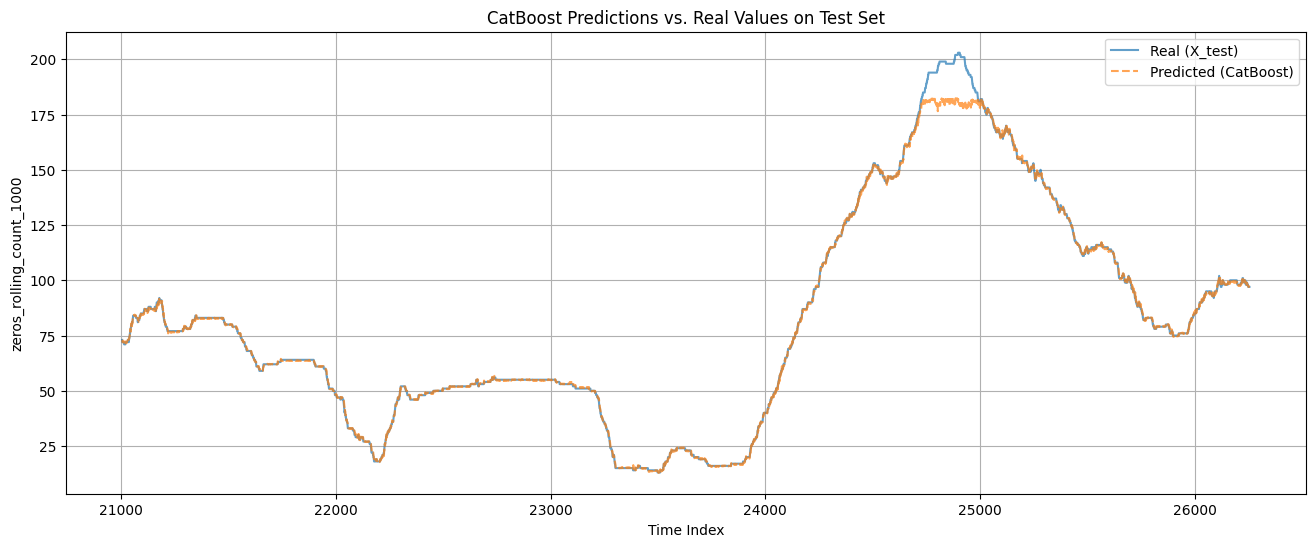

In [27]:
print('--- Chronological Train-Test Split for CatBoost Evaluation ---')

# Perform a chronological train-test split on df_catboost for model evaluation
# Split point: 80% for training, 20% for testing, maintaining time order
split_idx = int(len(df_catboost) * 0.8)

X_train_cat, X_test_cat = X_cat.iloc[:split_idx], X_cat.iloc[split_idx:]
y_train_cat, y_test_cat = y_cat.iloc[:split_idx], y_cat.iloc[split_idx:]

print(f"X_train_cat shape: {X_train_cat.shape}, y_train_cat shape: {y_train_cat.shape}")
print(f"X_test_cat shape: {X_test_cat.shape}, y_test_cat shape: {y_test_cat.shape}")

print('\n--- Training CatBoost Regressor ---')

# Initialize CatBoost Regressor
cat_model = CatBoostRegressor(
    random_seed=42,
    verbose=0, # Suppress verbose output during training
    iterations=1000, # Number of boosting iterations
    learning_rate=0.05,
    depth=8,
    eval_metric='RMSE',
    early_stopping_rounds=50 # Stop if RMSE on test set doesn't improve for 50 rounds
)

# Create CatBoost Pool objects for efficient handling of categorical features
train_pool = Pool(X_train_cat, y_train_cat, cat_features=cat_features_catboost)
test_pool  = Pool(X_test_cat, y_test_cat, cat_features=cat_features_catboost)

# Train the model
cat_model.fit(train_pool, eval_set=test_pool, use_best_model=True)

print('\n--- Evaluating CatBoost Regressor ---')

# Make predictions on the test set
y_pred_cat = cat_model.predict(X_test_cat)

# Evaluate the model
rmse_cat = np.sqrt(mean_squared_error(y_test_cat, y_pred_cat))
r2_cat = r2_score(y_test_cat, y_pred_cat)

print(f"CatBoost RMSE on test set: {rmse_cat:.4f}")
print(f"CatBoost R2 score on test set: {r2_cat:.4f}")

# Plot actual vs. predicted for CatBoost
plt.figure(figsize=(16, 6))
plt.plot(X_test_cat.index, y_test_cat, label='Real (X_test)', alpha=0.7)
plt.plot(X_test_cat.index, y_pred_cat, label='Predicted (CatBoost)', alpha=0.7, linestyle='--')
plt.title('CatBoost Predictions vs. Real Values on Test Set')
plt.xlabel('Time Index')
plt.ylabel(TARGET)
plt.legend()
plt.grid(True)
plt.show()

In [28]:
print('--- Generating Final Predictions for df_val using CatBoost ---')

# Predict on the df_val (out-of-sample) features
final_predictions_catboost = cat_model.predict(X_val_cat)

# Ensure predictions are non-negative
final_predictions_catboost = np.clip(final_predictions_catboost, 0, None)

# Create a submission DataFrame
submission_catboost = df_val.copy() # Use original df_val to get 'Unnamed: 0' and other identifiers
submission_catboost[TARGET] = final_predictions_catboost

# Save to CSV
submission_catboost[['Unnamed: 0', TARGET]].to_csv('final_predictions_catboost.csv', index=False)

print("Final CatBoost predictions saved to 'final_predictions_catboost.csv'")
print("Preview of final predictions:")
display(submission_catboost[['Unnamed: 0', TARGET]].head())

print('\n--- Conclusion for CatBoost Model ---')
print(f"The CatBoost model achieved an RMSE of {rmse_cat:.4f} and an R2 score of {r2_cat:.4f} on the evaluation test set.")
print("This indicates a significant improvement over the ARIMA model, especially in capturing the patterns over time.")
print("The ability to incorporate lag features and handle non-linearities makes CatBoost a more suitable choice for this long-term forecasting task.")

--- Generating Final Predictions for df_val using CatBoost ---
Final CatBoost predictions saved to 'final_predictions_catboost.csv'
Preview of final predictions:


,Unnamed: 0,zeros_rolling_count_1000
0,26266,97.655949
1,26267,89.970860
2,26268,83.621316
3,26269,79.097012
4,26270,73.292670



--- Conclusion for CatBoost Model ---
The CatBoost model achieved an RMSE of 3.4924 and an R2 score of 0.9950 on the evaluation test set.
This indicates a significant improvement over the ARIMA model, especially in capturing the patterns over time.
The ability to incorporate lag features and handle non-linearities makes CatBoost a more suitable choice for this long-term forecasting task.


In [29]:
print("The `zeros_rolling_count_1000` column for `df_val` has been predicted using the CatBoost model.")
print("You can find these predictions in the `submission_catboost` DataFrame:")

display(submission_catboost[['Unnamed: 0', TARGET]].head())
display(submission_catboost[['Unnamed: 0', TARGET]].tail())

print("\nThis DataFrame effectively contains the 'created' `zeros_rolling_count_1000` column for `df_val` with the forecasted values. We cannot directly calculate `is_zero_popularity` or `zeros_rolling_count_1000` for `df_val` because its `track_popularity` values are unknown (NaN).")

The `zeros_rolling_count_1000` column for `df_val` has been predicted using the CatBoost model.
You can find these predictions in the `submission_catboost` DataFrame:


,Unnamed: 0,zeros_rolling_count_1000
0,26266,97.655949
1,26267,89.970860
2,26268,83.621316
3,26269,79.097012
4,26270,73.292670


,Unnamed: 0,zeros_rolling_count_1000
6562,32828,71.050121
6563,32829,71.209703
6564,32830,71.131163
6565,32831,71.233021
6566,32832,71.044861



This DataFrame effectively contains the 'created' `zeros_rolling_count_1000` column for `df_val` with the forecasted values. We cannot directly calculate `is_zero_popularity` or `zeros_rolling_count_1000` for `df_val` because its `track_popularity` values are unknown (NaN).


In [37]:
y_pred_cat.shape

(5250,)

In [35]:
submission_catboost[['Unnamed: 0', TARGET]]

,Unnamed: 0,zeros_rolling_count_1000
0,26266,97.655949
1,26267,89.970860
2,26268,83.621316
3,26269,79.097012
4,26270,73.292670
...,...,...
6562,32828,71.050121
6563,32829,71.209703
6564,32830,71.131163
6565,32831,71.233021


## Prediccion

In [38]:
df = pd.read_csv('/content/df_train_2_FE.csv')

df_val = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Datasets/df_val_2_FE_sinOutliers.csv')

df.dropna(inplace=True)
df['key'] = df['key'].astype(str)
df['mode'] = df['mode'].astype(str)
df['grupo_anio'] = df['grupo_anio'].astype(str)
df['len_playlist_name'] = df['len_playlist_name'].astype(str)
df['tonality'] = df['tonality'].astype(str)

# FE de tiempo
df['tiene_mes_y_dia'] = (df['track_album_release_date'].apply(lambda x: x.count('-')) == 2).astype(int)
serie_tiempo = pd.to_datetime(df.loc[df['tiene_mes_y_dia'] == 1, 'track_album_release_date'])
df['mes'] = 13
df.loc[df['tiene_mes_y_dia'] == 1, 'mes'] = serie_tiempo.dt.month
df['dia'] = 32
df.loc[df['tiene_mes_y_dia'] == 1, 'dia'] = serie_tiempo.dt.day
df['tiene_mes_y_dia'] = df['tiene_mes_y_dia'].astype(str)
df['mes'] = df['mes'].astype(str)
df['dia'] = df['dia'].astype(str)

df_val['tiene_mes_y_dia'] = (df_val['track_album_release_date'].apply(lambda x: x.count('-')) == 2).astype(int)
serie_tiempo = pd.to_datetime(df_val.loc[df_val['tiene_mes_y_dia'] == 1, 'track_album_release_date'])
df_val['mes'] = 13
df_val.loc[df_val['tiene_mes_y_dia'] == 1, 'mes'] = serie_tiempo.dt.month
df_val['dia'] = 32
df_val.loc[df_val['tiene_mes_y_dia'] == 1, 'dia'] = serie_tiempo.dt.day
df_val['tiene_mes_y_dia'] = df_val['tiene_mes_y_dia'].astype(str)
df_val['mes'] = df_val['mes'].astype(str)
df_val['dia'] = df_val['dia'].astype(str)


df['is_zero_popularity'] = (df['track_popularity'] == 0).astype(int)
df['zeros_rolling_count_1000'] = df['is_zero_popularity'].rolling(window=1000, min_periods=1).sum()

In [39]:
cols = ['Unnamed: 0','track_artist', 'playlist_name', 'playlist_id',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'grupo_anio',
       'distance_mean_danceability', 'distance_sq_mean_danceability', 'distance_mean_energy',
       'distance_sq_mean_energy', 'distance_mean_loudness',
       'distance_sq_mean_loudness', 'distance_mean_speechiness',
       'distance_sq_mean_speechiness', 'distance_mean_acousticness',
       'distance_sq_mean_acousticness', 'distance_mean_liveness',
       'distance_sq_mean_liveness', 'distance_mean_valence',
       'distance_sq_mean_valence', 'distance_mean_tempo',
       'distance_sq_mean_tempo', 'dance_energy', 'happy_energy',
       'acoustic_instr', 'duration_min', 'track_age', 'len_playlist_name',
       'log_instrumentalness', 'log_speechiness', 'log_liveness', 'z_danceability', 'z_energy', 'z_loudness', 'z_tempo',
       'z_valence', 'z_acousticness', 'z_instrumentalness', 'z_speechiness',
       'global_atipicality', 'max_z_score',
       'most_extreme_feature', 'mood_score', 'chill_score', 'melancholy_score',
       'radio_friendly', 'club_score', 'acoustic_contrast', 'mood_complexity',
       'dance_val_tension', 'vocal_presence', 'pure_instrumental',
       'spoken_word', 'loudness_abs', 'loudness_energy_ratio',
       'dynamic_compression', 'live_vocal', 'studio_clean', 'danceability_sq',
       'danceability_sqrt', 'energy_sq', 'energy_sqrt', 'valence_sq',
       'valence_sqrt', 'loudness_abs_sq', 'loudness_abs_sqrt', 'tonality',
        'tiene_mes_y_dia', 'mes', 'dia', 'zeros_rolling_count_1000']

dummies_genre = pd.get_dummies(df['playlist_genre']).astype(int)
dummies_subgenre = pd.get_dummies(df['playlist_subgenre']).astype(int)
genre_imp = dummies_genre[['r&b']]
subgenre_imp = dummies_subgenre[['neo soul']]

copia = df.copy()

df_1 = pd.concat([copia[cols], genre_imp, subgenre_imp], axis=1)

df_1['distance_mean_duration_min'] = (df['duration_min'] - df['duration_min'].mean())
df_1['distance_sq_mean_duration_min'] = (df_1['distance_mean_duration_min'])**2
df_1['log_duration_min'] = np.log(df['duration_min'])
df_1['z_duration_min'] = (df['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()

df_1['r&b'] = df_1['r&b'].astype(str)
df_1['neo soul'] = df_1['neo soul'].astype(str)

In [40]:
X = df_1.copy()
y = df['track_popularity'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_true, X_val, y_train_true, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

cat_features = df_1.select_dtypes(include='object').columns.tolist()
train_pool = Pool(X_train_true, y_train_true, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features)

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.025,
    loss_function='RMSE',
    eval_metric='RMSE',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)

# ── ENTRENAMIENTO ──────────────────────────────────────────────
model.fit(train_pool, eval_set=val_pool)

print('TRAIN')
y_pred = model.predict(X_train_true)
print(f"R²:   {r2_score(y_train_true, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train_true, y_pred)):.4f}")

print('VAL')
y_pred = model.predict(X_val)
print(f"R²:   {r2_score(y_val, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred)):.4f}")

print('TEST')
y_pred = model.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

0:	learn: 24.8601619	test: 24.5168477	best: 24.5168477 (0)	total: 154ms	remaining: 2m 33s
100:	learn: 19.5797830	test: 18.8208433	best: 18.8208433 (100)	total: 13s	remaining: 1m 55s
200:	learn: 18.8905050	test: 18.4175368	best: 18.4175368 (200)	total: 23.4s	remaining: 1m 32s
300:	learn: 18.5845175	test: 18.2390463	best: 18.2390463 (300)	total: 29.6s	remaining: 1m 8s
400:	learn: 18.3332375	test: 18.1072253	best: 18.1072253 (400)	total: 37.2s	remaining: 55.6s
500:	learn: 18.0674247	test: 17.9617101	best: 17.9617101 (500)	total: 43.3s	remaining: 43.2s
600:	learn: 17.8486094	test: 17.9055124	best: 17.9048479 (598)	total: 50.8s	remaining: 33.7s
700:	learn: 17.6537245	test: 17.8560213	best: 17.8560213 (700)	total: 57s	remaining: 24.3s
800:	learn: 17.4914699	test: 17.8181111	best: 17.8181111 (800)	total: 1m 4s	remaining: 16s
900:	learn: 17.3422971	test: 17.7909834	best: 17.7909620 (899)	total: 1m 11s	remaining: 7.82s
999:	learn: 17.1979093	test: 17.7643441	best: 17.7638455 (994)	total: 1m 18s

In [49]:
model.get_feature_importance(prettified=True).head(25)

,Feature Id,Importances
0,track_artist,19.804330
1,playlist_id,13.291923
2,playlist_name,11.162093
3,grupo_anio,8.433067
4,dia,7.049617
5,track_age,5.389276
6,zeros_rolling_count_1000,2.710453
7,Unnamed: 0,2.560393
8,len_playlist_name,2.009997
9,tonality,1.915297


In [43]:
df_val['zeros_rolling_count_1000'] = submission_catboost['zeros_rolling_count_1000']

In [45]:
df_val_ML = df_val.copy()
df_val_ML['r&b'] = (df_val['playlist_genre'] == 'r&b').astype(int).rename('r&b')
df_val_ML['neo soul'] = (df_val['playlist_subgenre'] == 'neo soul').astype(int).rename('neo soul')
df_val_ML['distance_mean_duration_min'] = (df_val_ML['duration_min'] - df['duration_min'].mean())
df_val_ML['distance_sq_mean_duration_min'] = (df_val_ML['distance_mean_duration_min'])**2
df_val_ML['log_duration_min'] = np.log(df['duration_min'])
df_val_ML['z_duration_min'] = (df['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()
df_val_ML['r&b'] = df_val_ML['r&b'].astype(str)
df_val_ML['neo soul'] = df_val_ML['neo soul'].astype(str)

df_val_ML = df_val_ML[X_train_true.columns.to_list()]

pred_val = model.predict(df_val_ML)

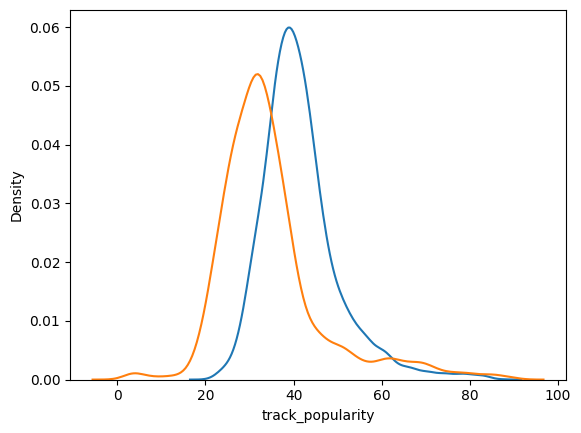

In [47]:
sns.kdeplot(pred_val)
best_pred_2575 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/avg_leak_plus_track_id_2575.csv')
sns.kdeplot(best_pred_2575['track_popularity'])
plt.show()